# GLM

In [2]:
import os
import sys

import numpy as np
import pandas as pd
import polars as pl

os.chdir("../../")
sys.path.insert(0, os.getcwd())

In [3]:
import statsmodels.api as sm

In [4]:
from morai import models
from morai.experience import charters, tables
from morai.forecast import metrics, preprocessors
from morai.utils import custom_logger, helpers

In [5]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

## Logistic Formula

### Partial Prediction

A logistic regression is of the form:

$$
p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}
$$

The odds ratio determines the increase with a value change in the variable defined as:

$$
odds = \frac{p}{1-p}
$$

If wanting to adjust a value using a base probabilty the probability first needs to be transformed to odds and then adjusted and transformed back

$$
\displaylines{
\text{base\_odds} = \frac{p}{1-p} \\
\text{adj\_odds} = \text{base\_odds} \cdot \text{new\_odds} \\
\text{new\_prob} = \frac{\text{adj\_odds}}{1 + \text{adj\_odds}}
}
$$


Creating a test dataset to show how the parameters of a glm are used.

In [5]:
# dataset where sex is 111% for  1 and face is 50% for 1
data = {
    "sex": [0, 0, 1, 1],
    "face": [0, 1, 0, 1],
    "rate": [0.45000, 0.22500, 0.50000, 0.25000],
}
df = pd.DataFrame(data)

preprocess_dict = preprocessors.preprocess_data(
    df,
    feature_dict={
        "target": ["rate"],
        "weight": [],
        "passthrough": ["sex", "face"],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

# model the data
GLM = models.core.GLM()
GLM.fit(X, y)

 2025-11-27 11:37:55 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 11:37:55 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 11:37:55 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['face', 'sex', 'constant'] 
 2025-11-27 11:37:55 | morai.models.core | INFO     | fiting the model 
 2025-11-27 11:37:55 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE5CC4EB40> family... 


In [6]:
print(GLM.model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   rate   No. Observations:                    4
Model:                            GLM   Df Residuals:                        1
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1.6432
Date:                Thu, 27 Nov 2025   Deviance:                   0.00020453
Time:                        11:37:56   Pearson chi2:                 0.000205
No. Iterations:                     4   Pseudo R-squ. (CS):            0.06201
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
constant      -0.1875      1.784     -0.105      0.9

In [7]:
odds = GLM.get_odds()
params = GLM.model.params

 2025-11-27 11:37:56 | morai.models.core | INFO     | generating odds ratio from model 


The logistic regression can be calculated using the parameters or by using the odds ratios to adjust a partial prediction. 

As can be seen the GLM is not able to perfectly predict the rates as the transformed function (log odds) is not perfectly linear. When the rates are large (>.2) there is a larger difference in the predictions. It is for this reason that the mean rate should be used if rates are large, however if rates are small there won't be much of a difference.


In [8]:
# parameters
sex = 1
face = 1

# calculate probability using logistic formula
probability = 1 / (
    1 + np.exp(-(params["constant"] + params["sex"] * sex + params["face"] * face))
)
print(f"probability: {probability}")

# calculate probability from partial prediction
base = 1 / (1 + np.exp(-(params["constant"])))
base_odd = base / (1 - base)
sex_odd = np.exp((params["sex"]) * sex)
face_odd = np.exp((params["face"]) * face)
adj_odd = base_odd * sex_odd * face_odd
new_prob = adj_odd / (1 + adj_odd)
print(f"new_prob: {new_prob}")

probability: 0.2532711191974117
new_prob: 0.25327111919741174


In [9]:
odds["sex"]

np.float64(1.1905054025326711)

In [10]:
odds["face"]

np.float64(0.34364127209085565)

### Categorization Multiplier

The rate of a multiplier from a logistic regression will be different based on the value of the rate it is applied to. The multiplier will be lower the higher the rate.

In [11]:
rates = X.copy()

In [12]:
rate_table_mult, mult_table = tables.generate_table(
    model=GLM.model,
    mapping=preprocess_dict["mapping"],
    preprocess_feature_dict=preprocess_dict["feature_dict"],
    preprocess_params=preprocess_dict["params"],
    mult_features=["sex"],
)
tables.output_table(
    rate_table=rate_table_mult, filename="simple_glm_mults.xlsx", mult_table=mult_table
)

 2025-11-27 11:38:02 | morai.experience.tables | INFO     | generating table for model GLMResultsWrapper 
 2025-11-27 11:38:02 | morai.experience.tables | WARNING  | THIS IS EXPERIMENTAL: the multipliers most likely not match the predictions exactly from the model and is used to simplify the output. 
 2025-11-27 11:38:02 | morai.experience.tables | INFO     | creating multiplier table based on the 'glm' 
 2025-11-27 11:38:02 | morai.experience.tables | INFO     | mult_table rows: 2 
 2025-11-27 11:38:02 | morai.experience.tables | INFO     | rate_table shape: (2, 3) 
 2025-11-27 11:38:03 | morai.experience.tables | INFO     | saving table to C:\Users\johnk\Desktop\github\morai\files\rates\simple_glm_mults.xlsx 


In [13]:
rate_table_full, _ = tables.generate_table(
    model=GLM.model,
    mapping=preprocess_dict["mapping"],
    preprocess_feature_dict=preprocess_dict["feature_dict"],
    preprocess_params=preprocess_dict["params"],
)
tables.output_table(rate_table=rate_table_full, filename="simple_glm.csv")

 2025-11-27 11:38:03 | morai.experience.tables | INFO     | generating table for model GLMResultsWrapper 
 2025-11-27 11:38:03 | morai.experience.tables | INFO     | rate_table shape: (4, 4) 
 2025-11-27 11:38:03 | morai.experience.tables | INFO     | saving table to C:\Users\johnk\Desktop\github\morai\files\rates\simple_glm.csv 


In [14]:
rates = tables.map_rates(
    df=rates, rate="simple_glm_mults", rate_filename="rate_map_example.yaml"
)
rates = tables.map_rates(
    df=rates, rate="simple_glm", rate_filename="rate_map_example.yaml"
)

 2025-11-27 11:38:04 | morai.experience.tables | INFO     | mapping rate: 'qx_simple_glm_mults' with format: 'workbook' 
 2025-11-27 11:38:04 | morai.experience.tables | INFO     | the mapped rates are based on the following keys: ['face', 'sex'] 
 2025-11-27 11:38:04 | morai.experience.tables | INFO     | mapping rate: 'qx_simple_glm' with format: 'csv' 
 2025-11-27 11:38:04 | morai.experience.tables | INFO     | the mapped rates are based on the following keys: ['face', 'sex'] 


In [15]:
grouped = (
    rates.groupby(["face", "sex"])
    .agg({"qx_simple_glm_mults": "mean", "qx_simple_glm": "mean"})
    .unstack()
)
df_ratio = pd.DataFrame(
    {
        "ratio_mult": grouped["qx_simple_glm_mults"][0]
        / grouped["qx_simple_glm_mults"][1],
        "ratio_full": grouped["qx_simple_glm"][0] / grouped["qx_simple_glm"][1],
    }
)
df_ratio = df_ratio.reset_index()

In [16]:
charters.compare_rates(df_ratio, x_axis="face", rates=["ratio_mult", "ratio_full"])

In [17]:
df_ratio["ratio_full"].mean()

np.float64(0.8939863448671495)

In [18]:
df_ratio["ratio_mult"].mean()

np.float64(0.8399793884787156)

## Separate vs. Interaction Models

This is a simple example to see the impact of creating separate models for each curve or to use interaction variables. In this simple example the `old_rate` are increasing 10% each age while the `new_rate` are increasing 5% each age.

- if you are able to perfectly separate data relationships then the model predictions will be the same. If you aren't able to separate data `interaction` model does not provide the forecast precision as a `separation` model does.
- `cat` model calculates the exact curve

In [19]:
model_data = pd.read_csv("notebooks/files/simple_data_diff_curves.csv")
model_data = model_data[["era", "age", "uw", "rate"]]

In [20]:
model_data.head()

,era,age,uw,rate
0,old,10,s,0.10000
1,old,20,s,0.11000
2,old,30,s,0.12100
3,old,40,s,0.13310
4,old,50,s,0.14641


In [21]:
old_data = model_data[model_data["era"] == "old"]
new_data = model_data[model_data["era"] == "new"]

In [27]:
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict={
        "target": ["rate"],
        "passthrough": ["age"],
        "ohe": [
            "era",
            "uw",
        ],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
X["age_era"] = X["age"] * X["era_old"]
X["era_uw"] = X["era_old"] * X["uw_s"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

GLM = models.core.GLM()
GLM.fit(X, y)

predictions = GLM.model.predict(X)
model_data["interaction"] = predictions

 2025-11-27 12:07:06 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:07:06 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:07:06 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-11-27 12:07:06 | morai.forecast.preprocessors | INFO     | nominal - one hot encoded (dropping first col): ['uw', 'era'] 
 2025-11-27 12:07:06 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:07:06 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE5CBC4A70> family... 


In [29]:
for dataset, rate in [(old_data, "old"), (new_data, "new")]:
    preprocess_dict = preprocessors.preprocess_data(
        dataset,
        feature_dict={
            "target": ["rate"],
            "passthrough": ["age"],
            "ohe": [
                "uw",
            ],
        },
        standardize=False,
        add_constant=True,
    )

    X = preprocess_dict["X"]
    y = preprocess_dict["y"]
    weights = preprocess_dict["weights"]
    mapping = preprocess_dict["mapping"]

    GLM = models.core.GLM()
    GLM.fit(X, y)

    predictions = GLM.model.predict(X)
    model_data[rate] = predictions
model_data["separate"] = model_data["new"].combine_first(model_data["old"])
model_data = model_data.drop(columns=["new", "old"])

 2025-11-27 12:07:15 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:07:15 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:07:15 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-11-27 12:07:15 | morai.forecast.preprocessors | INFO     | nominal - one hot encoded (dropping first col): ['uw'] 
 2025-11-27 12:07:15 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:07:15 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE62A245F0> family... 
 2025-11-27 12:07:15 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:07:15 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:07:15 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 202

In [30]:
GLM.get_odds()

 2025-11-27 12:07:17 | morai.models.core | INFO     | generating odds ratio from model 


age         1.005367
constant    0.028809
uw_s        2.870977
dtype: float64

In [31]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1000, learning_rate=0.1, depth=7, cat_features=["uw", "era"]
)
model.fit(model_data[["age", "uw", "era"]], model_data[["rate"]], verbose=0)

In [32]:
predictions = model.predict(model_data[["age", "uw", "era"]])
model_data["cat"] = predictions

In [33]:
model_data["i_div_r"] = model_data["interaction"] / model_data["rate"]
model_data["s_div_r"] = model_data["separate"] / model_data["rate"]
model_data["c_div_r"] = model_data["cat"] / model_data["rate"]

In [34]:
charters.compare_rates(
    model_data[(model_data["era"] == "new") & (model_data["uw"] == "ns")],
    x_axis="age",
    rates=["i_div_r", "s_div_r", "c_div_r"],
)

In [35]:
new = model_data[(model_data["era"] == "new") & (model_data["uw"] == "ns")]
old = model_data[(model_data["era"] == "old") & (model_data["uw"] == "ns")][
    ["era", "age", "uw", "rate"]
]
merge_new = new.merge(old, how="left", on=["age", "uw"], suffixes=["_new", "_old"])

In [36]:
charters.compare_rates(
    merge_new,
    x_axis="age",
    rates=["rate_new", "rate_old", "interaction", "separate", "cat"],
)

### Extrapolating

Extrapolating rates from a model using unknown datapoints can cause incorrect conclusions.

A `interaction` versus a `separate` model will produce the same results so long as the `interaction` perfectly separates the data. 

The model does not produce the curve shape without further manipulation.

In [37]:
model_data = pd.read_csv("notebooks/files/simple_data_diff_curve_speed.csv")
model_data = model_data[["speed", "age", "uw", "rate"]]
full_data = model_data.copy()
model_data = model_data[model_data["age"] <= 60]

In [38]:
model_data.head()

,speed,age,uw,rate
0,slow,10,s,0.10000
1,slow,20,s,0.11000
2,slow,30,s,0.12100
3,slow,40,s,0.13310
4,slow,50,s,0.14641


In [40]:
# model data
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict={
        "target": ["rate"],
        "passthrough": ["age"],
        "ohe": [
            "speed",
            "uw",
        ],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
X["age_speed"] = X["age"] * X["speed_slow"]
X["speed_uw"] = X["speed_slow"] * X["uw_s"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

GLM = models.core.GLM()
GLM.fit(X, y)

# full data
preprocess_dict = preprocessors.preprocess_data(
    full_data,
    feature_dict={
        "target": ["rate"],
        "passthrough": ["age"],
        "ohe": [
            "speed",
            "uw",
        ],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
X["age_speed"] = X["age"] * X["speed_slow"]
X["speed_uw"] = X["speed_slow"] * X["uw_s"]

predictions = GLM.model.predict(X)
full_data["interaction"] = predictions

 2025-11-27 12:07:44 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:07:44 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:07:44 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-11-27 12:07:44 | morai.forecast.preprocessors | INFO     | nominal - one hot encoded (dropping first col): ['speed', 'uw'] 
 2025-11-27 12:07:44 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:07:44 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE6296DEE0> family... 
 2025-11-27 12:07:44 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:07:44 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:07:44 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constan

In [41]:
for rate in ["slow", "fast"]:
    # model data
    preprocess_dict = preprocessors.preprocess_data(
        model_data[model_data["speed"] == rate],
        feature_dict={
            "target": ["rate"],
            "passthrough": ["age"],
            "ohe": [
                "uw",
            ],
        },
        standardize=False,
        add_constant=True,
    )

    X = preprocess_dict["X"]
    y = preprocess_dict["y"]
    weights = preprocess_dict["weights"]
    mapping = preprocess_dict["mapping"]

    GLM = models.core.GLM()
    GLM.fit(X, y)

    # full data
    preprocess_dict = preprocessors.preprocess_data(
        full_data[full_data["speed"] == rate],
        feature_dict={
            "target": ["rate"],
            "passthrough": ["age"],
            "ohe": [
                "uw",
            ],
        },
        standardize=False,
        add_constant=True,
    )

    X = preprocess_dict["X"]

    predictions = GLM.model.predict(X)
    full_data[rate] = predictions
full_data["separate"] = full_data["fast"].combine_first(full_data["slow"])
full_data = full_data.drop(columns=["fast", "slow"])

 2025-11-27 12:07:49 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:07:49 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:07:49 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-11-27 12:07:49 | morai.forecast.preprocessors | INFO     | nominal - one hot encoded (dropping first col): ['uw'] 
 2025-11-27 12:07:49 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:07:49 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE6296DEE0> family... 
 2025-11-27 12:07:49 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:07:49 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:07:49 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 202

In [42]:
GLM.get_odds()

 2025-11-27 12:07:51 | morai.models.core | INFO     | generating odds ratio from model 


age         1.016959
constant    0.024009
uw_s        2.899187
dtype: float64

In [43]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1000, learning_rate=0.1, depth=7, cat_features=["uw", "speed"]
)
model.fit(model_data[["age", "uw", "speed"]], model_data[["rate"]], verbose=0)

In [44]:
predictions = model.predict(full_data[["age", "uw", "speed"]])
full_data["cat"] = predictions

In [45]:
fast = full_data[(full_data["speed"] == "fast") & (full_data["uw"] == "s")]
slow = full_data[(full_data["speed"] == "slow") & (full_data["uw"] == "s")][
    ["speed", "age", "uw", "rate"]
]
merge_fast = fast.merge(slow, how="left", on=["age", "uw"], suffixes=["_fast", "_slow"])

In [46]:
charters.compare_rates(
    merge_fast,
    x_axis="age",
    rates=["rate_fast", "rate_slow", "interaction", "separate", "cat"],
)

### Blending

When data from one model runs out the data the model will use the data from other data unless it is split out


In [47]:
model_data = pd.read_csv("notebooks/files/simple_data_diff_curves.csv")
model_data = model_data[["era", "age", "uw", "rate"]]
full_data = model_data.copy()
model_data = model_data[
    ((model_data["era"] == "new") & (model_data["age"] <= 60))
    | (model_data["era"] == "old")
]

In [48]:
old_data = model_data[model_data["era"] == "old"]
new_data = model_data[model_data["era"] == "new"]

In [49]:
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict={
        "target": ["rate"],
        "passthrough": ["age"],
        "ohe": [
            "era",
            "uw",
        ],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
# X["age_era"] = X["age"] * X["era_old"]
X["era_uw"] = X["era_old"] * X["uw_s"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

GLM = models.core.GLM()
GLM.fit(X, y)

# full data
preprocess_dict = preprocessors.preprocess_data(
    full_data,
    feature_dict={
        "target": ["rate"],
        "passthrough": ["age"],
        "ohe": [
            "era",
            "uw",
        ],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
# X["age_era"] = X["age"] * X["era_old"]
X["era_uw"] = X["era_old"] * X["uw_s"]

predictions = GLM.model.predict(X)
full_data["interaction"] = predictions

 2025-11-27 12:08:04 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:08:04 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:08:04 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-11-27 12:08:04 | morai.forecast.preprocessors | INFO     | nominal - one hot encoded (dropping first col): ['uw', 'era'] 
 2025-11-27 12:08:04 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:08:04 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE6105CCE0> family... 
 2025-11-27 12:08:04 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:08:04 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:08:04 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'

In [50]:
for rate in ["old", "new"]:
    # model data
    preprocess_dict = preprocessors.preprocess_data(
        model_data[model_data["era"] == rate],
        feature_dict={
            "target": ["rate"],
            "passthrough": ["age"],
            "ohe": [
                "uw",
            ],
        },
        standardize=False,
        add_constant=True,
    )

    X = preprocess_dict["X"]
    y = preprocess_dict["y"]
    weights = preprocess_dict["weights"]
    mapping = preprocess_dict["mapping"]

    GLM = models.core.GLM()
    GLM.fit(X, y)

    # full data
    preprocess_dict = preprocessors.preprocess_data(
        full_data[full_data["era"] == rate],
        feature_dict={
            "target": ["rate"],
            "passthrough": ["age"],
            "ohe": [
                "uw",
            ],
        },
        standardize=False,
        add_constant=True,
    )

    X = preprocess_dict["X"]

    predictions = GLM.model.predict(X)
    full_data[rate] = predictions
full_data["separate"] = full_data["new"].combine_first(full_data["old"])
full_data = full_data.drop(columns=["new", "old"])

 2025-11-27 12:08:10 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:08:10 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:08:10 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-11-27 12:08:10 | morai.forecast.preprocessors | INFO     | nominal - one hot encoded (dropping first col): ['uw'] 
 2025-11-27 12:08:10 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:08:10 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE6105CCE0> family... 
 2025-11-27 12:08:10 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:08:10 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:08:10 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 202

In [51]:
new = full_data[(full_data["era"] == "new") & (full_data["uw"] == "s")]
old = full_data[(full_data["era"] == "old") & (full_data["uw"] == "s")][
    ["era", "age", "uw", "rate"]
]
merge_new = new.merge(old, how="left", on=["age", "uw"], suffixes=["_new", "_old"])

In [52]:
charters.compare_rates(
    merge_new,
    x_axis="age",
    rates=["rate_new", "rate_old", "interaction", "separate"],
)

In [53]:
new = full_data[(full_data["era"] == "new") & (full_data["uw"] == "s")][
    ["era", "age", "uw", "rate"]
]
old = full_data[(full_data["era"] == "old") & (full_data["uw"] == "s")]
merge_old = old.merge(new, how="left", on=["age", "uw"], suffixes=["_old", "_new"])

In [54]:
charters.compare_rates(
    merge_old,
    x_axis="age",
    rates=["rate_new", "rate_old", "interaction", "separate"],
)

### Blending Test

When data from one model runs out the data the model will use the data from other data unless it is split out


In [55]:
model_data = pd.read_csv("notebooks/files/simple_data_easy.csv")
model_data = model_data[["era", "age", "rate"]]
full_data = model_data.copy()
model_data = model_data[
    ((model_data["era"] == "new") & (model_data["age"] <= 80))
    | (model_data["era"] == "old")
]

In [56]:
old_data = model_data[model_data["era"] == "old"]
new_data = model_data[model_data["era"] == "new"]

In [58]:
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict={
        "target": ["rate"],
        "passthrough": ["age"],
        "ohe": [
            "era",
        ],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
# X["age_era"] = X["age"] * X["era_old"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

GLM = models.core.GLM()
GLM.fit(X, y)

# full data
preprocess_dict = preprocessors.preprocess_data(
    full_data,
    feature_dict={
        "target": ["rate"],
        "passthrough": ["age"],
        "ohe": [
            "era",
        ],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
# X["age_era"] = X["age"] * X["era_old"]

predictions = GLM.model.predict(X)
full_data["combined"] = predictions

 2025-11-27 12:08:27 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:08:27 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:08:27 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-11-27 12:08:27 | morai.forecast.preprocessors | INFO     | nominal - one hot encoded (dropping first col): ['era'] 
 2025-11-27 12:08:27 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:08:27 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE6105CCE0> family... 
 2025-11-27 12:08:27 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:08:27 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:08:27 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 20

In [59]:
for rate in ["old", "new"]:
    # model data
    preprocess_dict = preprocessors.preprocess_data(
        model_data[model_data["era"] == rate],
        feature_dict={
            "target": ["rate"],
            "passthrough": ["age"],
            "ohe": [],
        },
        standardize=False,
        add_constant=True,
    )

    X = preprocess_dict["X"]
    y = preprocess_dict["y"]
    weights = preprocess_dict["weights"]
    mapping = preprocess_dict["mapping"]

    GLM = models.core.GLM()
    GLM.fit(X, y)

    # full data
    preprocess_dict = preprocessors.preprocess_data(
        full_data[full_data["era"] == rate],
        feature_dict={
            "target": ["rate"],
            "passthrough": ["age"],
            "ohe": [],
        },
        standardize=False,
        add_constant=True,
    )

    X = preprocess_dict["X"]

    predictions = GLM.model.predict(X)
    full_data[rate] = predictions
full_data["separate"] = full_data["new"].combine_first(full_data["old"])
full_data = full_data.drop(columns=["new", "old"])

 2025-11-27 12:08:32 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:08:32 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:08:32 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-11-27 12:08:32 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:08:32 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE62786960> family... 
 2025-11-27 12:08:32 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:08:32 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:08:32 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-11-27 12:08:32 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:08:32 | morai.forecas

In [60]:
new = full_data[(full_data["era"] == "new")]
old = full_data[(full_data["era"] == "old")][["era", "age", "rate"]]
merge_new = new.merge(old, how="left", on=["age"], suffixes=["_new", "_old"])

In [61]:
charters.compare_rates(
    merge_new,
    x_axis="age",
    rates=["rate_new", "rate_old", "combined", "separate"],
)

In [62]:
new = full_data[(full_data["era"] == "new")][["era", "age", "rate"]]
old = full_data[(full_data["era"] == "old")]
merge_old = old.merge(new, how="left", on=["age"], suffixes=["_old", "_new"])

In [63]:
charters.compare_rates(
    merge_old,
    x_axis="age",
    rates=["rate_new", "rate_old", "combined", "separate"],
)

## Historical Improvement

This is a simple example that is comparing between 2 scenarios.
1. **rate:** historical experience *is not* adjusted for mortality improvment
2. **rate_adj:** historical *is* adjusted for mortality improvement

In [64]:
model_data = pd.read_csv("tests/files/forecast/models/simple_data.csv")

In [65]:
forecast_list = [
    {
        "rate": "pred_rate",
        "feature_dict": {
            "target": ["rate"],
            "weight": [],
            "passthrough": ["year", "gender"],
        },
    },
    {
        "rate": "pred_rate_adj",
        "feature_dict": {
            "target": ["rate_adj"],
            "weight": [],
            "passthrough": ["gender"],
        },
    },
    {
        "rate": "pred_rate_gender",
        "feature_dict": {
            "target": ["rate"],
            "weight": [],
            "passthrough": ["gender"],
        },
    },
]

In [66]:
for forecast in forecast_list:
    feature_dict = forecast["feature_dict"]
    rate = forecast["rate"]
    preprocess_dict = preprocessors.preprocess_data(
        model_data, feature_dict=feature_dict, standardize=False, add_constant=True
    )

    X = preprocess_dict["X"]
    y = preprocess_dict["y"]
    weights = preprocess_dict["weights"]
    mapping = preprocess_dict["mapping"]

    GLM = models.core.GLM()
    GLM.fit(X, y, weights)

    # print(GLM.model.summary())

    predictions = GLM.model.predict(X)
    model_data[rate] = predictions

# charters.pdp(model=GLM.model, df=model_data, x_axis="gender", mapping=mapping)

 2025-11-27 12:08:45 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:08:45 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:08:45 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['gender', 'year', 'constant'] 
 2025-11-27 12:08:45 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:08:45 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE6105CCE0> family... 
 2025-11-27 12:08:45 | morai.forecast.preprocessors | INFO     | model target: ['rate_adj'] 
 2025-11-27 12:08:45 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:08:45 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['gender', 'constant'] 
 2025-11-27 12:08:45 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:08:45 | morai.models

C:\Users\johnk\miniconda3\envs\morai\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning:

Perfect separation or prediction detected, parameter may not be identified

C:\Users\johnk\miniconda3\envs\morai\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning:

Perfect separation or prediction detected, parameter may not be identified



 2025-11-27 12:08:45 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:08:45 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:08:45 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['gender', 'constant'] 
 2025-11-27 12:08:45 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:08:45 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE6105CCE0> family... 


What happens with these predictions is following:
1. **pred_rate:** when predictin on study year and gender and these variables interact, the resulting rates will be a blend and not accurate.
2. **pred_rate_adj:** when predicting on gender after adjusting year rates are perfectly predicted
3. **pred_rate_gender:** when predicting on gender without adjusting year rates it predicts the average mortality (midpoint) and would also be accurate.

In [67]:
charters.compare_rates(
    model_data[model_data["gender"] == 1],
    x_axis="year",
    rates=["rate", "rate_adj", "pred_rate", "pred_rate_adj", "pred_rate_gender"],
)

## Weighting

This is a simple example compares a GLM when weighting vs. not weighting.
1. **weighting**: this will produce a rate that is close to .9
2. **non-weighted**: this will produce a rate that is the average regardless of weight

There are 2 ways to weight in statmodels (`var_weights` and `freq_weights`). Currently using the `var_weights` method. This method does not replicate the exposures but rather gives each exposure more influence.

In [68]:
model_data = pd.read_csv("tests/files/forecast/models/simple_data_extreme.csv")

In [69]:
model_data

,record,expose,rate,actual
0,1,1000000,0.9,900000.0
1,1,1,0.1,0.1


In [70]:
X = model_data["record"]
y = model_data["rate"]
success = model_data["actual"]
failure = model_data["expose"] - model_data["actual"]
weights = model_data["expose"]

In [71]:
GLM = models.core.GLM()
GLM.fit(X, y, weights)
predictions = GLM.model.predict(X)
predictions

 2025-11-27 12:08:54 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:08:54 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE65698EF0> family... 


0    0.899999
1    0.899999
dtype: float64

In [72]:
GLM = models.core.GLM()
GLM.fit(X, y)
predictions = GLM.model.predict(X)
predictions

 2025-11-27 12:08:55 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:08:55 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE6296DEB0> family... 


0    0.5
1    0.5
dtype: float64

In [73]:
GLM = models.core.GLM()
GLM.fit(X, pd.concat([success, failure], axis=1))
predictions = GLM.model.predict(X)
predictions

 2025-11-27 12:08:56 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:08:56 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE6296C3E0> family... 


0    0.899999
1    0.899999
dtype: float64

### Frequency vs. Variance Weighted

There was no difference between the predictions of the `var_weights` and `freq_weights`, however the number of residuals do change substantially. Due to using binomial distribution is also the reason as well.

In [74]:
# frequency
glm_freq = sm.GLM(
    endog=y, exog=X, family=sm.families.Binomial(), freq_weights=weights
).fit()
print(glm_freq.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   rate   No. Observations:                    2
Model:                            GLM   Df Residuals:                  1000000
Model Family:                Binomial   Df Model:                            0
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.3623e+05
Date:                Thu, 27 Nov 2025   Deviance:                       3.5156
Time:                        12:09:00   Pearson chi2:                     7.11
No. Iterations:                     6   Pseudo R-squ. (CS):         -8.731e-10
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
record         2.1972      0.003    659.167      0.0

In [75]:
# variance
glm_var = sm.GLM(
    endog=y, exog=X, family=sm.families.Binomial(), var_weights=weights
).fit()
print(glm_var.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   rate   No. Observations:                    2
Model:                            GLM   Df Residuals:                        1
Model Family:                Binomial   Df Model:                            0
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.3623e+05
Date:                Thu, 27 Nov 2025   Deviance:                       3.5156
Time:                        12:09:01   Pearson chi2:                     7.11
No. Iterations:                     6   Pseudo R-squ. (CS):         -8.731e-10
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
record         2.1972      0.003    659.167      0.0

In [76]:
model_data["qx_glm_freq"] = glm_freq.predict(X)
model_data["qx_glm_var"] = glm_var.predict(X)

In [77]:
model_data

,record,expose,rate,actual,qx_glm_freq,qx_glm_var
0,1,1000000,0.9,900000.0,0.899999,0.899999
1,1,1,0.1,0.1,0.899999,0.899999


## Credibility

### Importance

A basis of Buhlmann credibility is:
   - large number of observations -> increased credibility
   - mean of the hypothetical variances is small (EPV) -> increased credibility
   - variances of the mean are large (VHM) -> increased credibility

The formula is: $$\frac{N}{N + \left(\frac{\text{EPV}}{\text{VHM}}\right)}$$

Taking this in context of a logistic regression that differs by many features the credibility should be influenced by some features. Here are a few comments on those influences:

   - The most important features will have the largest influence on the rate. For example, for a mortality rate, attained age will have a larger influence than sex.
   - The larger the factor is for the rate the more important the function would be as well.



In [78]:
blend = pd.read_csv("tests/files/experience/blend_credibility.csv")

In [79]:
preprocess_dict = preprocessors.preprocess_data(
    blend,
    feature_dict={
        "target": ["rate"],
        "weight": ["exposure"],
        "passthrough": ["age", "sex", "risk", "sub", "rare"],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

 2025-11-27 12:09:08 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:09:08 | morai.forecast.preprocessors | INFO     | model weights: ['exposure'] 
 2025-11-27 12:09:08 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:09:08 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['rare', 'age', 'sub', 'risk', 'sex', 'constant'] 


In [81]:
GLM = models.core.GLM()
GLM.get_feature_contributions(X, y, weights=weights, base_features=["age"])

 2025-11-27 12:09:13 | morai.models.core | INFO     | generating feature contributions from model for 4 features by fitting the model and seeing the reduction in deviance. 
 2025-11-27 12:09:13 | morai.models.core | INFO     | base features: '['age', 'constant']' 


,features,contribution,deviance
0,all,1.000000,55.056802
1,base,0.000000,206.645490
2,rare,0.131959,75.060252
3,risk,0.411024,117.363459
4,sex,0.009708,56.528463
5,sub,0.411024,117.363459


In [82]:
GLM.get_odds()

 2025-11-27 12:09:56 | morai.models.core | INFO     | generating odds ratio from model 


rare        0.000404
risk        0.794471
sex         0.795323
sub         0.794471
age         1.036657
constant    0.002209
dtype: float64

### SHAP

In [83]:
import shap

shap.initjs()

In [84]:
explainer = shap.Explainer(GLM.model.predict, X)

C:\Users\johnk\miniconda3\envs\morai\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning:

overflow encountered in exp

ExactExplainer explainer:   2%|█▋                                                               | 1/40 [00:00<?, ?it/s]C:\Users\johnk\miniconda3\envs\morai\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning:

overflow encountered in exp

ExactExplainer explainer: 41it [00:21,  1.83it/s]                                                                      


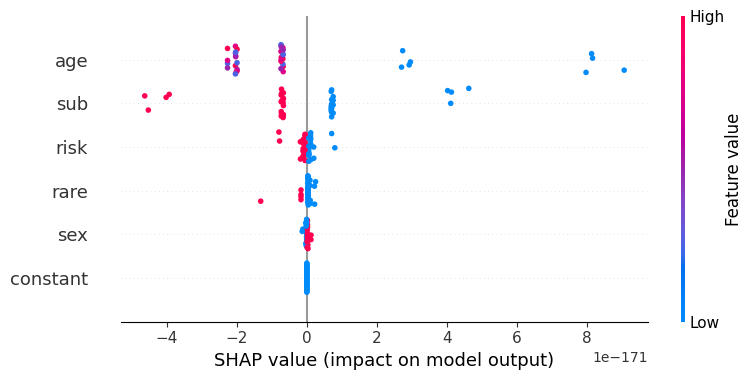

In [85]:
shap_values = explainer(X)
shap.summary_plot(shap_values, X)

C:\Users\johnk\miniconda3\envs\morai\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning:

overflow encountered in exp



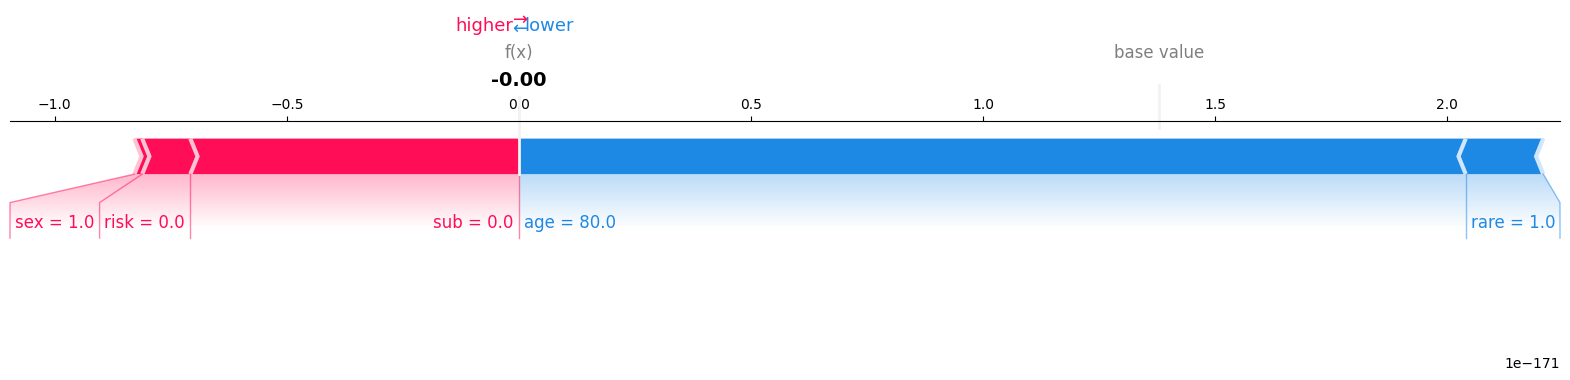

In [86]:
expected_value = np.mean(GLM.model.predict(X))
idx = 8
shap.force_plot(expected_value, shap_values.values[idx], X.iloc[idx], matplotlib=True)

### Grouping

In [87]:
pl_parquet_path = r"files/dataset/mortality_grouped.parquet"

In [88]:
# reading in the dataset
# `enable_string_cache` helps with categorical type values
pl.enable_string_cache()
lzdf = pl.scan_parquet(
    pl_parquet_path,
)

In [89]:
initial_row_count = lzdf.select(pl.len()).collect().item()
print(
    f"row count: {initial_row_count:,} \n"
    f"exposures: {lzdf.select([pl.col('amount_exposed').sum()]).collect()[0,0]:,}"
)

row count: 1,522,971 
exposures: 9,054,258,435,620.062


In [90]:
grouped_df = lzdf.collect()

In [91]:
grouped_df = grouped_df.to_pandas()

In [92]:
def get_importance(features, values):
    importance = pd.DataFrame({"feature": features, "importance": values})
    importance = importance.sort_values(by="importance", ascending=False)
    return importance

In [93]:
grouped_df["binned_attained_age"] = preprocessors.bin_feature(
    grouped_df["attained_age"], 22
)
grouped_df["binned_attained_age"] = grouped_df["binned_attained_age"].astype("category")

In [94]:
feature_dict = {
    "target": ["qx_raw"],
    "weight": ["amount_exposed"],
    "passthrough": ["attained_age", "duration"],
    "ordinal": [
        "smoker_status",
        "binned_attained_age",
    ],
    "ohe": [],
    "nominal": [],
}

In [95]:
preprocess_dict = preprocessors.preprocess_data(
    grouped_df,
    feature_dict=feature_dict,
    standardize=False,
    add_constant=True,
)

 2025-11-27 12:10:27 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2025-11-27 12:10:27 | morai.forecast.preprocessors | INFO     | model weights: ['amount_exposed'] 
 2025-11-27 12:10:27 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:10:27 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['attained_age', 'duration', 'constant'] 
 2025-11-27 12:10:27 | morai.forecast.preprocessors | INFO     | ordinal - ordinal encoded: ['smoker_status', 'binned_attained_age'] 


In [96]:
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]
md_encoded = preprocess_dict["md_encoded"]
model_features = preprocess_dict["model_features"]

In [98]:
GLM = models.core.GLM()

In [99]:
GLM.get_feature_contributions(X, y, base_features=[])

 2025-11-27 12:10:44 | morai.models.core | INFO     | generating feature contributions from model for 4 features by fitting the model and seeing the reduction in deviance. 
 2025-11-27 12:10:44 | morai.models.core | INFO     | base features: '['constant']' 


,features,contribution,deviance
0,all,1.000000,95770.051164
1,base,0.000000,132354.165833
2,attained_age,0.006842,96020.347194
3,binned_attained_age,0.000002,95770.114685
4,duration,0.019208,96472.745573
5,smoker_status,0.031271,96914.086243


In [100]:
GLM.fit(
    X=X[["constant", "duration", "smoker_status", "binned_attained_age"]],
    y=y,
    r_style=False,
)

 2025-11-27 12:11:58 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:11:58 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE71B57E00> family... 


In [101]:
GLM.model.deviance

np.float64(96020.34719406879)

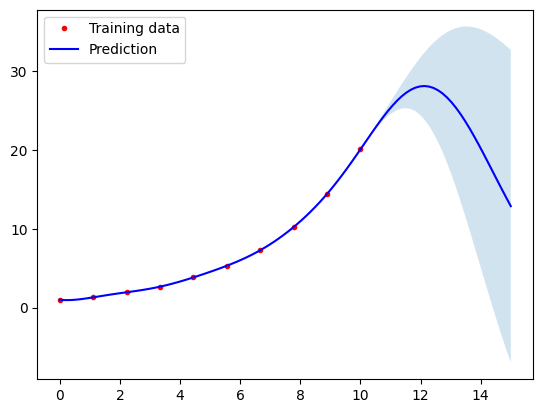

In [102]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import ConstantKernel as C

# Generate exponential data
X = np.linspace(0, 10, 10).reshape(-1, 1)
y = np.exp(0.3 * X).ravel() + np.random.normal(0, 0.1, X.shape[0])

# Define the kernel (RBF = Radial Basis Function)
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=2.0, length_scale_bounds=(1e-2, 1e2))

# Fit Gaussian Process
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gp.fit(X, y)

# Predict with uncertainty
X_pred = np.linspace(0, 15, 100).reshape(-1, 1)
y_pred, sigma = gp.predict(X_pred, return_std=True)

import matplotlib.pyplot as plt

plt.plot(X, y, "r.", label="Training data")
plt.plot(X_pred, y_pred, "b-", label="Prediction")
plt.fill_between(X_pred.ravel(), y_pred - 2 * sigma, y_pred + 2 * sigma, alpha=0.2)
plt.legend()
plt.show()

## Feature Engineering

In [103]:
full_data = pd.read_csv("notebooks/files/simple_data_features.csv")
full_data = full_data[["era", "age", "rate"]]
model_data = full_data.copy()
model_data["age_sqrd"] = model_data["age"] ** 2
model_data["age_sqrt"] = model_data["age"] ** 0.5

In [104]:
# [age]
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict={
        "target": ["rate"],
        "weight": [],
        "passthrough": [
            "age",
        ],
    },
    standardize=False,
    add_constant=True,
)
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

# model the data
GLM = models.core.GLM()
GLM.fit(X, y)
model_data["pred_age"] = GLM.model.predict(X)

 2025-11-27 12:16:33 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:16:33 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:16:33 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-11-27 12:16:33 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:16:33 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE7075C860> family... 


In [105]:
# [age, age_sqrd]
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict={"target": ["rate"], "weight": [], "passthrough": ["age", "age_sqrd"]},
    standardize=False,
    add_constant=True,
)
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

# model the data
GLM = models.core.GLM()
GLM.fit(X, y)
model_data["pred_age_age_sqrd"] = GLM.model.predict(X)

 2025-11-27 12:16:36 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:16:36 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:16:36 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age_sqrd', 'age', 'constant'] 
 2025-11-27 12:16:36 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:16:36 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE717F41D0> family... 


In [106]:
# [age, age_sqrt, age_sqrd]
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict={
        "target": ["rate"],
        "weight": [],
        "passthrough": ["age", "age_sqrd", "age_sqrt"],
    },
    standardize=False,
    add_constant=True,
)
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

# model the data
GLM = models.core.GLM()
GLM.fit(X, y)
model_data["pred_age_age_sqrt_age_sqrd"] = GLM.model.predict(X)

 2025-11-27 12:16:39 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:16:39 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:16:39 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age_sqrt', 'age_sqrd', 'age', 'constant'] 
 2025-11-27 12:16:39 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:16:39 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE7186DEE0> family... 


In [107]:
# [age, age_sqrt]
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict={
        "target": ["rate"],
        "weight": [],
        "passthrough": ["age", "age_sqrt"],
    },
    standardize=False,
    add_constant=True,
)
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

# model the data
GLM = models.core.GLM()
GLM.fit(X, y)
model_data["pred_age_age_sqrt"] = GLM.model.predict(X)

 2025-11-27 12:16:40 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:16:40 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:16:40 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age_sqrt', 'age', 'constant'] 
 2025-11-27 12:16:40 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:16:40 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE7186DEE0> family... 


In [109]:
charters.compare_rates(
    model_data,
    x_axis="age",
    rates=[
        "rate",
        "pred_age",
        "pred_age_age_sqrd",
        "pred_age_age_sqrt_age_sqrd",
        "pred_age_age_sqrt",
    ],
)

## Test

In [ ]:
helpers.memory_usage_jupyter()

In [76]:
helpers.memory_usage_jupyter_cells("glm.ipynb")

 2025-05-12 00:52:16 | morai.utils.helpers | INFO     | getting largest cells for C:\Users\johnk\Desktop\github\morai\notebooks\tutorials\glm.ipynb 


,cell_idx,cell_type,size_kb,preview
90,90,code,302.9,import shap shap.initjs()
92,92,code,37.0,shap_values = explainer(X) shap.summary_plot(s...
93,93,code,32.7,expected_value = np.mean(GLM.model.predict(X))...
46,46,code,20.9,"charters.compare_rates( merge_fast, x_..."
73,73,code,20.8,charters.compare_rates( model_data[model_d...
35,35,code,20.8,"charters.compare_rates( merge_new, x_a..."
56,56,code,20.2,"charters.compare_rates( merge_old, x_a..."
66,66,code,20.2,"charters.compare_rates( merge_old, x_a..."
54,54,code,20.2,"charters.compare_rates( merge_new, x_a..."
64,64,code,20.1,"charters.compare_rates( merge_new, x_a..."


In [6]:
from morai.integrations import hmd

db_filepath = r"files/integrations/hmd/hmd.sql"
hmd_usa_df = hmd.get_hmd_data_sql(db_filepath=db_filepath, table_name="hmd")
hmd_usa_df = hmd_usa_df[(hmd_usa_df["year"] >= 1950) & (hmd_usa_df["year"] <= 2023)]
hmd_usa_df["qx_raw"] = hmd_usa_df["total_death"] / hmd_usa_df["total_exposure"]

In [7]:
preprocess_dict = preprocessors.preprocess_data(
    hmd_usa_df,
    feature_dict={
        "target": ["qx_raw"],
        "weight": [],
        "passthrough": [
            "year",
            "age",
        ],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

 2025-11-28 12:28:14 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2025-11-28 12:28:14 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-28 12:28:14 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'year', 'constant'] 


In [35]:
GLM = models.core.GLM()
res = GLM.fit(X, y)

 2025-11-28 13:11:57 | morai.models.core | INFO     | fiting the model 
 2025-11-28 13:11:57 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x0000013A3318FF50> family... 


In [69]:
GLM.model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 qx_raw   No. Observations:                 8214
Model:                            GLM   Df Residuals:                     8211
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1095.9
Date:                Fri, 28 Nov 2025   Deviance:                       91.055
Time:                        13:50:38   Pearson chi2:                     349.
No. Iterations:                     8   Pseudo R-squ. (CS):             0.1903
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
age            0.0874      0.003     26.277      0.000       0.081       0.094
constant     -17.2914      4.270     -4.050      0.000     -25.660      -8.923
year           0.0040      0.002      1.860      0.063      -0.000       0.008
==============================================================================
"""

In [9]:
predictions = GLM.predict(X)

In [37]:
import importlib

importlib.reload(charters)

<module 'morai.experience.charters' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\experience\\charters.py'>

In [65]:
residuals = pd.DataFrame(
    {
        "deviance": GLM.model.resid_deviance,
        "pearson": GLM.model.resid_pearson,
        "fitted": predictions,
    }
)

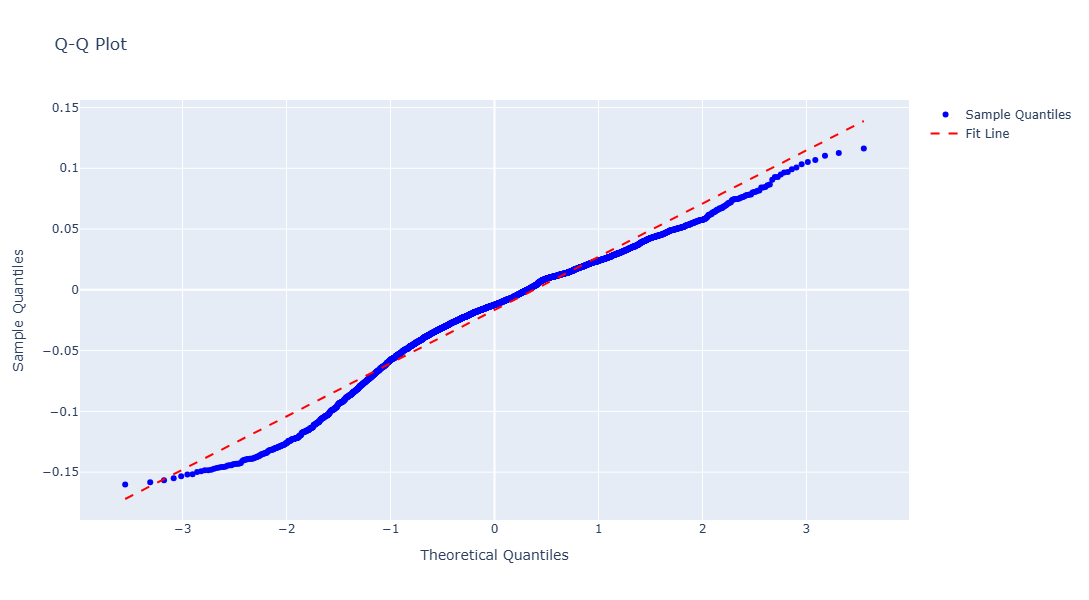

In [63]:
mask = (X["age"] > 30) & (X["age"] < 80)
charters.qq(GLM.model.resid_pearson[mask])

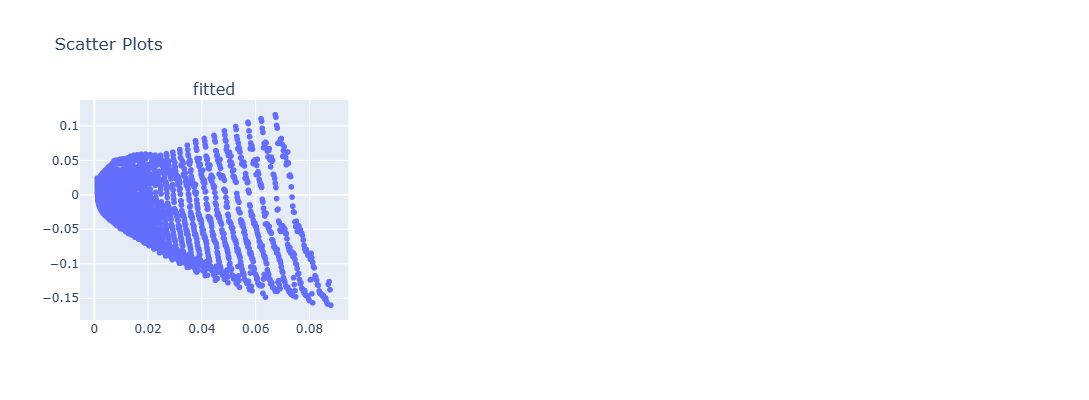

In [70]:
charters.scatter(residuals[mask], target="pearson", features=["fitted"], sample_nbr=None)